# Implémentation de la méthode CDF-t

## Importation des bibliothèques

In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from functions import ( 
    csv_to_pd_univ, 
    cdf_t_univ, 
    plot_distributions,
    comparer_distributions,
    extract_month_data
)

import numpy as np
import pandas as pd
from scipy import stats

## Implémentation CDF-t univariée (température)

### Comparaison passé/futur dans le modèle et dans les observations (observations futures = valeurs corrigées)

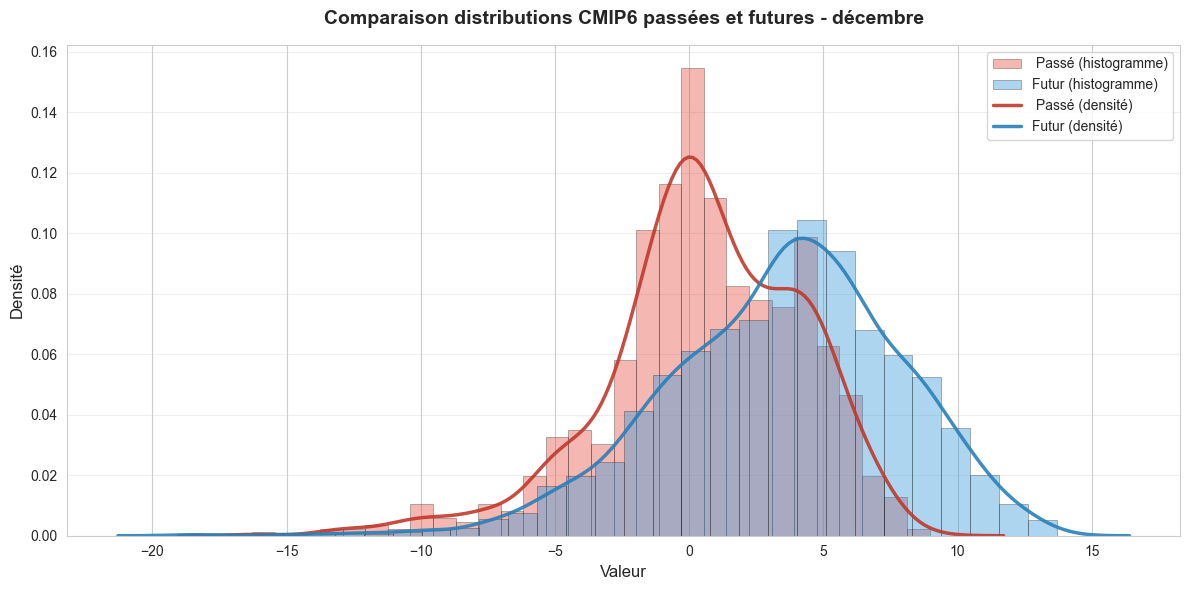

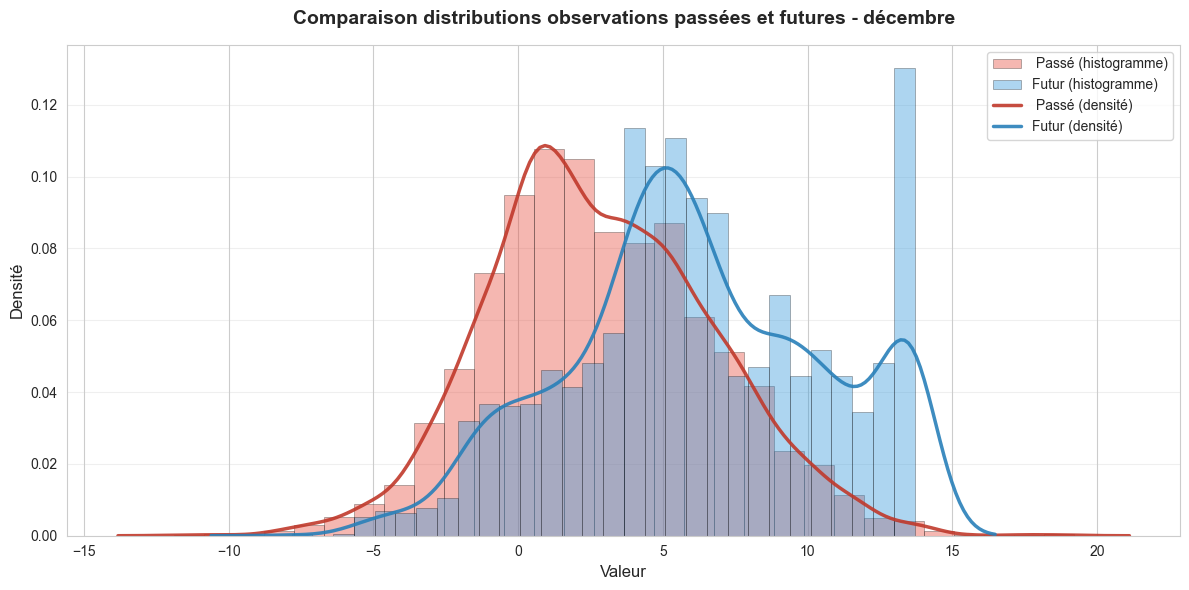

In [ ]:
CMIP6_hist = csv_to_pd_univ(r"data/CMIP6_historical.csv", 12, "tas", years = (1982,2014))
CMIP6_futur = csv_to_pd_univ(r"data/CMIP6_ssp585.csv", 12, "tas", years= (2015,2100))
obs_hist = csv_to_pd_univ(r"data/obs.csv", 12, "tas", years= (1982,2014))
_ ,modele_futur_corrige  = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur) 

#Représentations graphiques
plot_distributions((CMIP6_hist, CMIP6_futur),"Comparaison distributions CMIP6 passées et futures - décembre",("Passé","Futur"))
plot_distributions((obs_hist,modele_futur_corrige),"Comparaison distributions observations passées et futures - décembre",("Passé","Futur") )

### Comparaison modèle/observations dans le passé et dans le futur (avec valeurs corrigées)

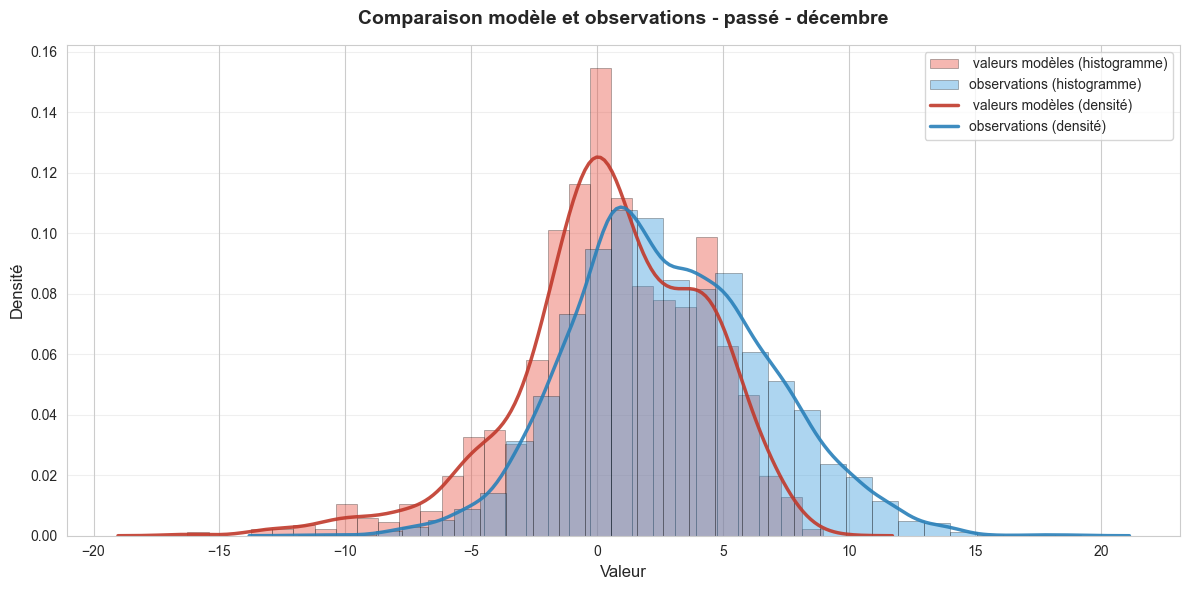

In [ ]:
#Comparaison passé

#Sélection mois et variable
CMIP6_hist = csv_to_pd_univ(r"data/CMIP6_historical.csv", 12, "tas", years = (1982,2014))
obs_hist = csv_to_pd_univ(r"data/obs.csv", 12, "tas", years = (1982,2014)) 

#Représentation graphique
plot_distributions((CMIP6_hist, obs_hist),
                           "Comparaison modèle et observations - passé - décembre",
                           ("valeurs modèles","observations"))

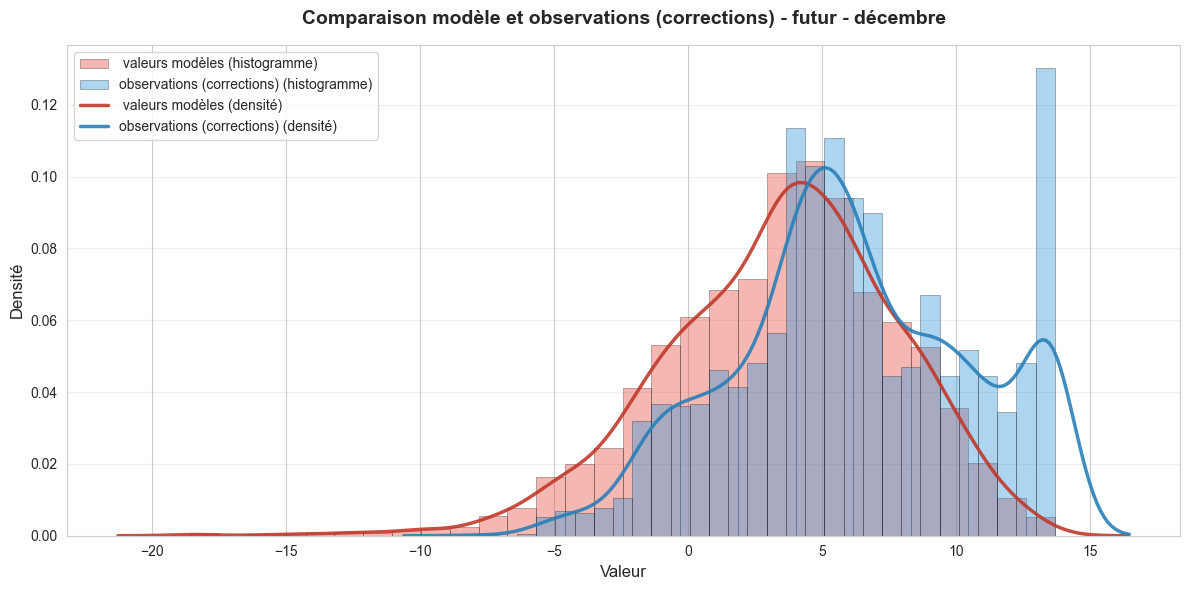

In [ ]:
#Comparaison futur 

#Sélection mois et variable
CMIP6_hist = csv_to_pd_univ(r"data/CMIP6_historical.csv", 12, "tas", years = (1982,2014))
CMIP6_futur = csv_to_pd_univ(r"data/CMIP6_ssp585.csv", 12, "tas", years= (2015,2100))
obs_hist = csv_to_pd_univ(r"data/obs.csv", 12, "tas", years = (1982,2014))

#Correction des valeurs futures du modèle par CDF-t
_ ,modele_futur_corrige  = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur) 

#Représentation graphique
plot_distributions((CMIP6_futur, modele_futur_corrige),
                           "Comparaison modèle et observations (corrections) - futur - décembre",
                           ("valeurs modèles","observations (corrections)"))

### Cas gaussien

Paramètres estimés (MLE) :
CMIP6_hist : μ=0.55, σ=3.67
CMIP6_futur : μ=3.48, σ=4.36
obs_hist : μ=2.86, σ=3.88

Paramètres de la loi X :
μ_X = 6.22
σ_X = 4.61


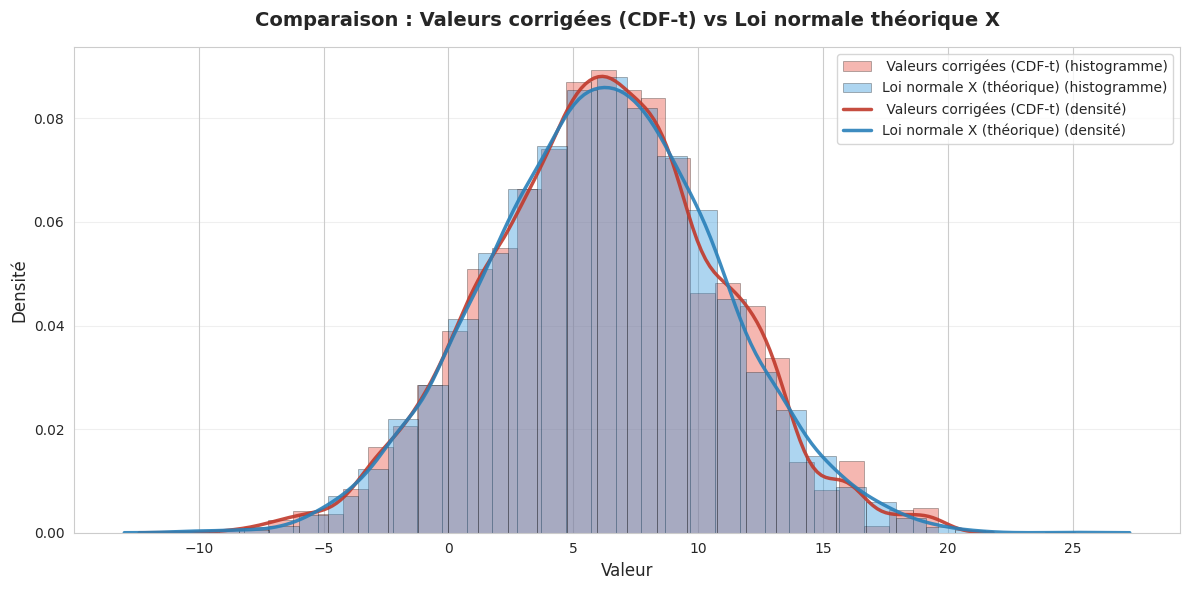

In [4]:
#Sélection mois et variable
CMIP6_hist = csv_to_pd_univ("data/CMIP6_historical.csv", 12, "tas", years = (1982,2014))
CMIP6_futur = csv_to_pd_univ("data/CMIP6_ssp585.csv", 12, "tas", years= (2015,2100))
obs_hist = csv_to_pd_univ("data/obs.csv", 12, "tas" , years = (1982,2014))


# ============================================================================
# ÉTAPE 1 : Estimer les paramètres des lois gaussiennes
# ============================================================================

# Extraire les données (supposant une seule colonne par DataFrame)
data_CMIP6_hist = CMIP6_hist.iloc[:, 0]
data_CMIP6_futur = CMIP6_futur.iloc[:, 0]
data_obs_hist = obs_hist.iloc[:, 0]

# Estimer les paramètres avec Maximum de Vraisemblance (MLE)
mu_CMIP6_hist, sigma_CMIP6_hist = stats.norm.fit(data_CMIP6_hist)
mu_CMIP6_futur, sigma_CMIP6_futur = stats.norm.fit(data_CMIP6_futur)
mu_obs_hist, sigma_obs_hist = stats.norm.fit(data_obs_hist)

print("Paramètres estimés (MLE) :")
print(f"CMIP6_hist : μ={mu_CMIP6_hist:.2f}, σ={sigma_CMIP6_hist:.2f}")
print(f"CMIP6_futur : μ={mu_CMIP6_futur:.2f}, σ={sigma_CMIP6_futur:.2f}")
print(f"obs_hist : μ={mu_obs_hist:.2f}, σ={sigma_obs_hist:.2f}")

# ============================================================================
# ÉTAPE 2 : Simuler 10000 valeurs pour chaque variable aléatoire
# ============================================================================

n_simulations = 10000

# Simuler depuis les lois gaussiennes estimées
sim_CMIP6_hist = np.random.normal(mu_CMIP6_hist, sigma_CMIP6_hist, n_simulations)
sim_CMIP6_futur = np.random.normal(mu_CMIP6_futur, sigma_CMIP6_futur, n_simulations)
sim_obs_hist = np.random.normal(mu_obs_hist, sigma_obs_hist, n_simulations)

# Créer les DataFrames
CMIP6_hist_norm = pd.DataFrame({'CMIP6_hist_sim': sim_CMIP6_hist})
CMIP6_futur_norm = pd.DataFrame({'CMIP6_futur_sim': sim_CMIP6_futur})
obs_hist_norm = pd.DataFrame({'obs_hist_sim': sim_obs_hist})

# ============================================================================
# ÉTAPE 3 : Appliquer la fonction cdf_t_univ
# ============================================================================

df_futur_sim, df_corrige = cdf_t_univ(CMIP6_hist_norm, obs_hist_norm, CMIP6_futur_norm)

# ============================================================================
# ÉTAPE 4 : Simuler la loi normale X avec les paramètres calculés
# ============================================================================

# Calculer les paramètres de X directement avec les paramètres estimés
mu_X = mu_CMIP6_futur + (mu_obs_hist - mu_CMIP6_hist) * (sigma_CMIP6_futur / sigma_CMIP6_hist)
sigma_X = sigma_obs_hist * (sigma_CMIP6_futur / sigma_CMIP6_hist)

print("\nParamètres de la loi X :")
print(f"μ_X = {mu_X:.2f}")
print(f"σ_X = {sigma_X:.2f}")

# Simuler X
sim_X = np.random.normal(mu_X, sigma_X, n_simulations)
df_X = pd.DataFrame({'X_theorique': sim_X})

# ============================================================================
# ÉTAPE 5 : Comparer les distributions avec plot_distributions
# ============================================================================

# Créer le tuple des DataFrames
dfs_tuple = (df_corrige, df_X)

# Créer le titre
titre = "Comparaison : Valeurs corrigées (CDF-t) vs Loi normale théorique X"

# Créer les labels
labels_tuple = ("Valeurs corrigées (CDF-t)", "Loi normale X (théorique)")

# Tracer les distributions
plot_distributions(dfs_tuple, titre, labels_tuple)



### Validation croisée avec CMIP6 et observations

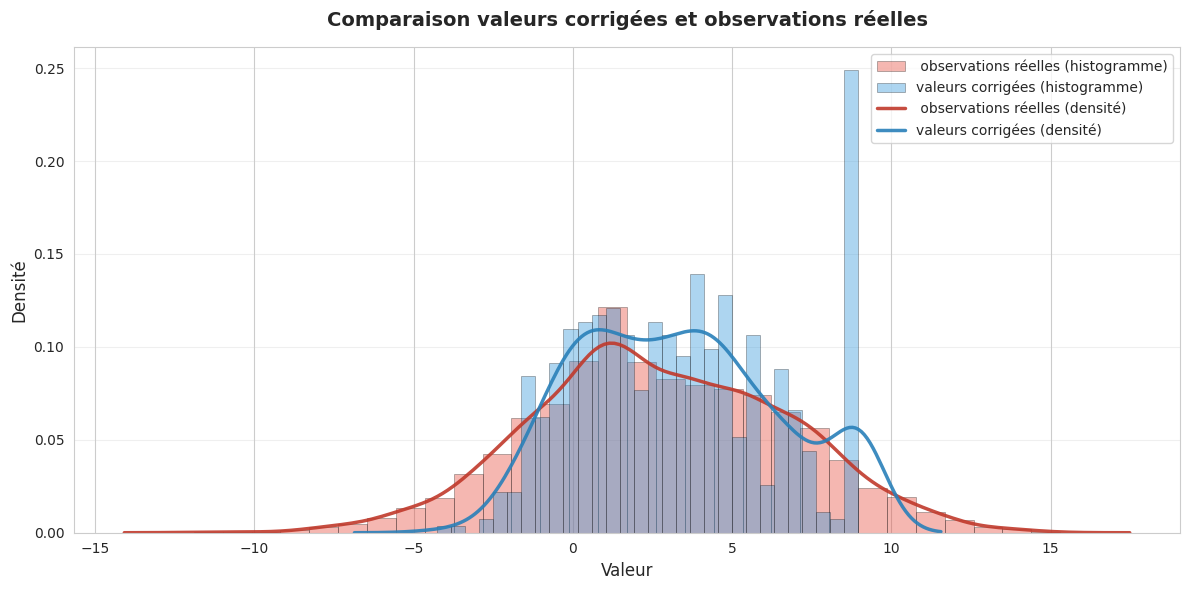

TypeError: comparer_distributions() takes 1 positional argument but 4 were given

In [9]:
#Sélection mois et variable
CMIP6_hist = csv_to_pd_univ(r"data/CMIP6_historical.csv", 12, "tas", years = (1975,1994))
CMIP6_futur = csv_to_pd_univ(r"data/CMIP6_historical.csv", 12, "tas", years= (1995,2014))
obs_hist = csv_to_pd_univ(r"data/obs.csv", 12, "tas", years = (1975,1994))
obs_futur = csv_to_pd_univ(r"data/obs.csv", 12, "tas", years = (1995,2014))

#Correction des valeurs futures du modèle par CDF-t
_ ,modele_futur_corrige  = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur) 

#Comparaison graphique et statistique
plot_distributions((obs_futur, modele_futur_corrige),
                    "Comparaison valeurs corrigées et observations réelles",
                    ("observations réelles","valeurs corrigées"),)
print(comparer_distributions(obs_futur,"Observations réelles",modele_futur_corrige,"Valeurs corrigées"))

### Validation croisée avec CMIP5 et Eurocordex

In [ ]:
#Sélection mois et variable
CMIP5_hist = csv_to_pd_univ(r"data/CMIP5_historical.csv", 12, "tas", years = (1996,2005))
CMIP5_futur = csv_to_pd_univ(r"data/CMIP5_rcp85.csv", 12, "tas", years= (2081,2100))
obs_hist = csv_to_pd_univ(r"data/eurocordex_historical.csv", 12, "tas", years = (1996,2005))
obs_futur = csv_to_pd_univ(r"data/eurocordex_rcp85.csv", 12, "tas", years = (2081,2100))

#Correction des valeurs futures du modèle par CDF-t
_ ,modele_futur_corrige  = cdf_t_univ(CMIP5_hist,obs_hist,CMIP5_futur) 

#Représentation graphique
plot_distributions((obs_futur, modele_futur_corrige),
                    "Comparaison valeurs corrigées et observations réelles",
                    ("observations réelles","valeurs corrigées"),)
print(comparer_distributions(obs_futur,"Observations réelles",modele_futur_corrige,"Valeurs corrigées"))